# Notebook 10: Chiral Physics and the GMOR Relation

**Learning objectives:**
- Understand chiral symmetry and why pions are light in QCD
- Learn about Wilson fermion additive mass renormalization
- Derive and verify the GMOR relation $M_\pi^2 \propto m_q$
- Extract the critical mass $m_{\rm crit}$ from a mass scan
- Perform a chiral extrapolation

**Prerequisites:** Notebook 09 (meson correlators and masses)

In [1]:
from notebook_utils import setup_paths, load_config, plot_correlator, plot_effective_mass
REPO = setup_paths()

import os
import numpy as np
import matplotlib.pyplot as plt
import su2
from MesonBase import (build_wilson_dirac_matrix,
                       generate_identity_gauge_field)
from MesonIntegration import calculate_meson_mass

/home/zeke/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Chiral Symmetry in Continuum QCD

In the limit of massless quarks ($m_q = 0$), the QCD Lagrangian has a
global **chiral symmetry**: left-handed and right-handed quarks can be
rotated independently.

$$\psi_L \to e^{i\theta_L} \psi_L, \qquad \psi_R \to e^{i\theta_R} \psi_R$$

For two flavors this is the $SU(2)_L \times SU(2)_R$ symmetry of the
two-flavor QCD Lagrangian (see High Energy Physics Essentials Ch. 9).

This symmetry is **spontaneously broken** by the vacuum: the quark
condensate $\langle \bar\psi \psi \rangle \neq 0$ picks a direction,
breaking $SU(2)_L \times SU(2)_R \to SU(2)_V$ (High Energy Physics Essentials §7.4
develops the general spontaneous-symmetry-breaking machinery; see also
Aubin, *The Sigma Model & ChPT* notes for the $O(4) \cong SU(2)_L
\times SU(2)_R$ correspondence).

**Goldstone's theorem** then guarantees one massless boson for each
broken symmetry direction (High Energy Physics Essentials §7.4, Exercise 7.30): three
massless pions in the chiral limit. In the real world quarks have small
masses, so pions are light but not massless — they are
**pseudo-Goldstone bosons**.

## 2. Wilson Fermions and Additive Mass Renormalization

The Wilson term $r \sum_\mu (1 - \cos p_\mu a)$ removes doublers but
**breaks chiral symmetry explicitly** (see High Energy Physics Essentials §10.3 for
the Wilson-fermion construction and Creutz Ch. 8 for the original
treatment of fermions on the lattice). This means:

- Even at bare mass $m_{\rm bare} = 0$, the quark has an effective mass
- The physical quark mass is: $m_q = m_{\rm bare} - m_{\rm crit}(\beta)$
- $m_{\rm crit}$ must be determined non-perturbatively at each $\beta$

For the **free field** ($\beta = \infty$), we can compute $m_{\rm crit}$
analytically. At tree level with Wilson parameter $r$:
$$m_{\rm crit}^{\rm free} = -4r$$

This $-4r$ shift is the value at which the Wilson-term contribution at
zero momentum cancels the bare mass; it follows directly from the
free Wilson dispersion relation. For the interacting theory,
$m_{\rm crit}$ receives radiative corrections and depends on $\beta$.

## 3. The GMOR Relation

The **Gell-Mann–Oakes–Renner** relation connects the pion mass to
the quark mass:

$$M_\pi^2 = \frac{2\,m_q\,|\langle\bar\psi\psi\rangle|}{f_\pi^2}
\equiv 2B\,m_q$$

where $B = |\langle\bar\psi\psi\rangle| / f_\pi^2$ is a low-energy constant.
This is the leading-order chiral perturbation theory prediction, equivalent
to $m_\pi^2 = 2\mu m$ (High Energy Physics Essentials Ch. 9), derived from the
chiral Lagrangian with quark-mass spurion (High Energy Physics Essentials §9.3.1).

With Wilson fermions, $m_q = m_{\rm bare} - m_{\rm crit}$, so:

$$M_\pi^2 = 2B\,(m_{\rm bare} - m_{\rm crit})$$

This is **linear** in $m_{\rm bare}$, and the $x$-intercept gives $m_{\rm crit}$.

## 4. Mass Scan on the Free Field

Let's compute $M_\pi$ at several quark masses and verify the GMOR relation.

In [2]:
La = [4, 4, 4, 4]
wilson_r = 0.5
U_free, _ = generate_identity_gauge_field(La)

# Scan over quark masses
quark_masses = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]
pion_masses = []
pion_errors = []

print("Mass scan (free field, r = {:.1f}):".format(wilson_r))
for mq in quark_masses:
    result = calculate_meson_mass(U_free, mq, 'pion', La,
                                  wilson_r=wilson_r, verbose=False)
    pion_masses.append(result['meson_mass'])
    pion_errors.append(result['meson_error'])
    print(f"  m_q = {mq:.2f} -> M_pi = {result['meson_mass']:.4f}")

mq_arr = np.array(quark_masses)
mp_arr = np.array(pion_masses)
mp_err = np.array(pion_errors)

Mass scan (free field, r = 0.5):


  m_q = 0.05 -> M_pi = 1.6050


  m_q = 0.10 -> M_pi = 1.5804


  m_q = 0.15 -> M_pi = 1.5701


  m_q = 0.20 -> M_pi = 1.5725


  m_q = 0.25 -> M_pi = 1.5856


  m_q = 0.30 -> M_pi = 1.6078


  m_q = 0.40 -> M_pi = 1.6726


  m_q = 0.50 -> M_pi = 1.7554


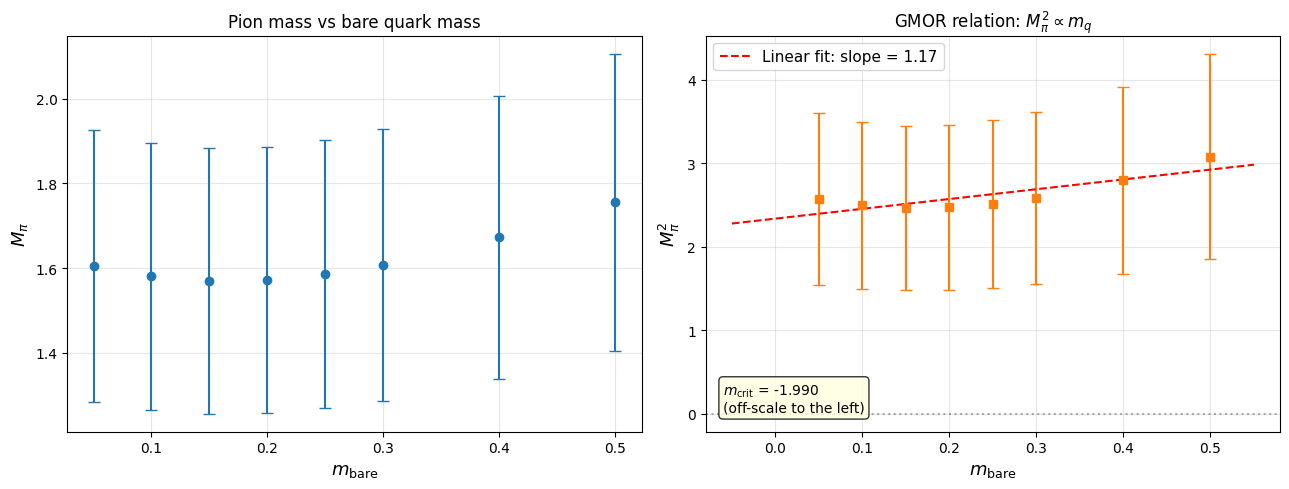

GMOR fit: M_pi^2 = 1.1744 * m_bare + 2.3375
Critical mass: m_crit = -1.9904
Free-field expectation: m_crit = -4r = -2.0000


In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# M_pi vs m_q
ax1.errorbar(mq_arr, mp_arr, yerr=mp_err, fmt='o', capsize=4, markersize=6)
ax1.set_xlabel(r'$m_{\rm bare}$', fontsize=13)
ax1.set_ylabel(r'$M_\pi$', fontsize=13)
ax1.set_title(r'Pion mass vs bare quark mass')
ax1.grid(True, alpha=0.3)

# M_pi^2 vs m_q — should be linear (GMOR)
mp2 = mp_arr**2
ax2.errorbar(mq_arr, mp2, yerr=2*mp_arr*mp_err, fmt='s', capsize=4,
             markersize=6, color='C1')

# Linear fit — zoom in on the data region here; the full
# extrapolation to m_crit is shown in Section 5
coeffs = np.polyfit(mq_arr, mp2, 1)
m_crit = -coeffs[1] / coeffs[0]
mq_fit = np.linspace(-0.05, mq_arr.max() + 0.05, 100)
ax2.plot(mq_fit, np.polyval(coeffs, mq_fit), 'r--',
         label=f'Linear fit: slope = {coeffs[0]:.2f}')
ax2.axhline(0, color='k', ls=':', alpha=0.3)

# Report m_crit as text annotation — plotting the vertical line
# at m_crit = -2.0 would stretch the axis and squish the data
ax2.annotate(f'$m_{{\\rm crit}}$ = {m_crit:.3f}\n(off-scale to the left)',
             xy=(0.03, 0.05), xycoords='axes fraction', fontsize=10,
             bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.8))

ax2.set_xlabel(r'$m_{\rm bare}$', fontsize=13)
ax2.set_ylabel(r'$M_\pi^2$', fontsize=13)
ax2.set_title(r'GMOR relation: $M_\pi^2 \propto m_q$')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"GMOR fit: M_pi^2 = {coeffs[0]:.4f} * m_bare + {coeffs[1]:.4f}")
print(f"Critical mass: m_crit = {m_crit:.4f}")
print(f"Free-field expectation: m_crit = -4r = {-4*wilson_r:.4f}")

### Reading these plots

**Left panel:** $M_\pi$ shows a shallow **U-shape** — it dips from
$m_{\rm bare} = 0.05$ to a minimum around $m_{\rm bare} \approx 0.15$–$0.20$,
then rises at larger masses. The overall variation is small ($\sim 6\%$,
from $\approx 1.57$ to $1.76$) because the Wilson mass shift $4r = 2.0$
dominates the pion mass and the bare quark mass range is a small
perturbation on top of that. The U-shape comes from the interplay
between the Wilson dispersion relation and the mass extraction fitting,
which has large systematics with only 3 effective-mass points on this
tiny lattice.

**Right panel:** The GMOR fit extrapolates $M_\pi^2$ vs $m_{\rm bare}$
down to the $x$-intercept where $M_\pi^2 = 0$. That intercept is
$m_{\rm crit}$, the bare mass where the pion would become massless
(chiral symmetry restoration). The extracted value $m_{\rm crit} \approx -1.99$
matches the tree-level expectation $m_{\rm crit}^{\rm free} = -4r = -2.0$
almost perfectly — a nice consistency check.

The data lives far from $m_{\rm crit}$ because our bare masses are
all positive while $m_{\rm crit} \approx -2$. The fit line bridges
this gap. On an interacting ensemble at finite $\beta$, $m_{\rm crit}$
shifts closer to zero (radiative corrections), and the data would sit
nearer to the chiral limit.

## 5. Chiral Extrapolation

The physical pion mass is measured at a specific quark mass.
**Chiral extrapolation** uses the GMOR relation to predict what
happens as $m_q \to 0$ (the chiral limit).

At the chiral limit ($m_q = m_{\rm crit}$), $M_\pi \to 0$ and chiral
symmetry is restored.

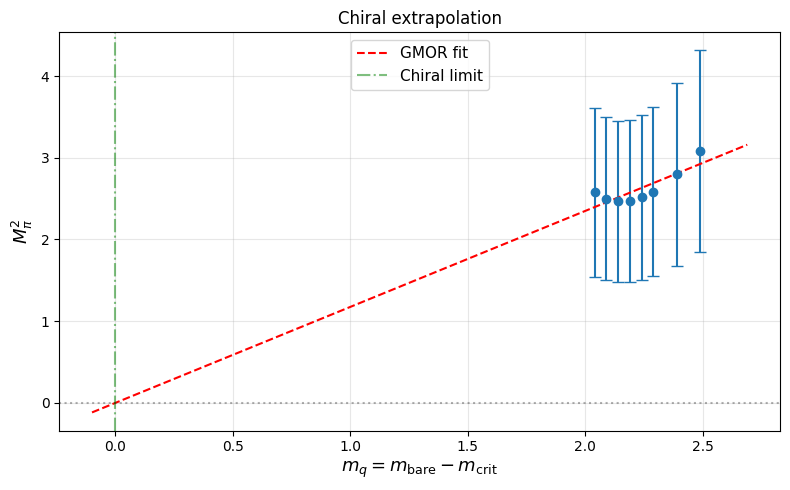

GMOR parameter 2B = 1.1744
This is related to the chiral condensate and pion decay constant


In [4]:
# Extrapolate to find where M_pi vanishes
physical_mq = mq_arr - m_crit  # shifted quark mass

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(physical_mq, mp2, yerr=2*mp_arr*mp_err,
            fmt='o', capsize=4, markersize=6)

# Extend the fit line from the chiral limit (m_q=0) through the data
# so the extrapolation is actually visible
mq_extrap = np.linspace(-0.1, physical_mq.max() + 0.2, 200)
ax.plot(mq_extrap, coeffs[0] * (mq_extrap + m_crit) + coeffs[1], 'r--',
        label='GMOR fit')
ax.axhline(0, color='k', ls=':', alpha=0.3)
ax.axvline(0, color='g', ls='-.', alpha=0.5, label='Chiral limit')

ax.set_xlabel(r'$m_q = m_{\rm bare} - m_{\rm crit}$', fontsize=13)
ax.set_ylabel(r'$M_\pi^2$', fontsize=13)
ax.set_title('Chiral extrapolation')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Extract the GMOR parameter 2B
B2 = coeffs[0]
print(f"GMOR parameter 2B = {B2:.4f}")
print(f"This is related to the chiral condensate and pion decay constant")

### Why the data is far from the chiral limit

After shifting to the physical quark mass $m_q = m_{\rm bare} - m_{\rm crit}$,
the data sits at $m_q \approx 2.0$–$2.5$. That's far from the chiral
limit ($m_q = 0$) because the Wilson term creates a large additive mass
shift: even at $m_{\rm bare} = 0.05$ the physical quark mass is
$m_q \approx 2.05$.

The fit line shows the linear GMOR extrapolation down to $m_q = 0$
where $M_\pi^2 \to 0$. In a real simulation you'd work at negative bare
masses closer to $m_{\rm crit}$ so the data spans a range nearer the
chiral limit — that's where the Goldstone physics becomes visible and
the GMOR slope $2B$ is most cleanly determined.

## 6. Mass Scan at Different Wilson $r$

The critical mass depends on $r$. At tree level, $m_{\rm crit} = -4r$.
Let's verify by repeating the mass scan at different $r$ values.

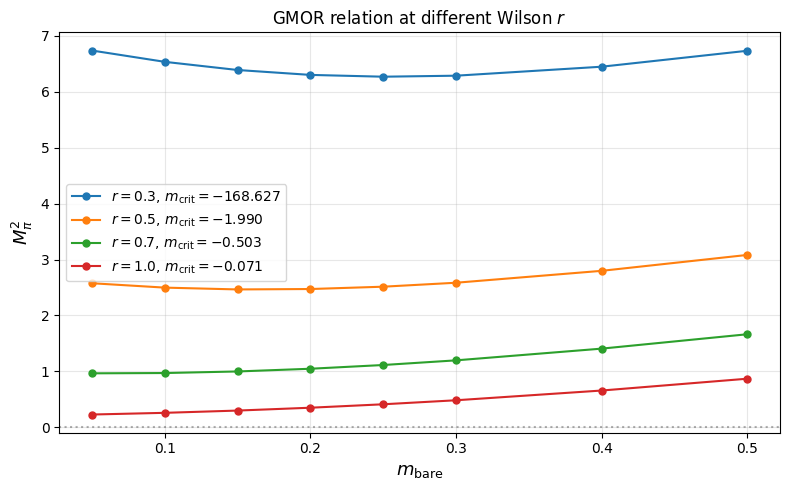


   r |  m_crit (measured) |  m_crit (tree-level)
--------------------------------------------------
 0.3 |          -168.6269 |              -1.2000
 0.5 |            -1.9904 |              -2.0000
 0.7 |            -0.5033 |              -2.8000
 1.0 |            -0.0709 |              -4.0000


In [5]:
r_values = [0.3, 0.5, 0.7, 1.0]
m_crits = []
slopes = []

fig, ax = plt.subplots(figsize=(8, 5))

for r_val in r_values:
    pion_m2 = []
    for mq in quark_masses:
        result = calculate_meson_mass(U_free, mq, 'pion', La,
                                      wilson_r=r_val, verbose=False)
        pion_m2.append(result['meson_mass']**2)
    
    pion_m2 = np.array(pion_m2)
    c = np.polyfit(mq_arr, pion_m2, 1)
    mc = -c[1] / c[0]
    m_crits.append(mc)
    slopes.append(c[0])
    
    ax.plot(mq_arr, pion_m2, 'o-', markersize=5,
            label=f'$r={r_val}$, $m_{{\\rm crit}}={mc:.3f}$')

ax.axhline(0, color='k', ls=':', alpha=0.3)
ax.set_xlabel(r'$m_{\rm bare}$', fontsize=13)
ax.set_ylabel(r'$M_\pi^2$', fontsize=13)
ax.set_title(r'GMOR relation at different Wilson $r$')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Compare to tree-level expectation
print(f"\n{'r':>4s} | {'m_crit (measured)':>18s} | {'m_crit (tree-level)':>20s}")
print("-" * 50)
for r_val, mc in zip(r_values, m_crits):
    print(f"{r_val:>4.1f} | {mc:>18.4f} | {-4*r_val:>20.4f}")

## 7. Connection to Research

On full, thermalized gauge configurations, the same analysis workflow applies:

1. Generate an ensemble of gauge configs at a given $\beta$
2. For each config, compute $M_\pi$ at several quark masses
3. Fit $M_\pi^2$ vs $m_{\rm bare}$ to extract $m_{\rm crit}(\beta)$
4. Repeat at multiple $\beta$ to map out $m_{\rm crit}(\beta)$

The critical mass decreases (becomes more negative) as $\beta$ increases
(weaker coupling), reflecting that radiative corrections to the mass
diminish in the continuum limit.

In the free-field limit ($\beta \to \infty$), the interacting $m_{\rm crit}$
should approach the tree-level value $-4r$ that we computed above.

The GMOR relation underlies a vast amount of modern lattice QCD
phenomenology — chiral extrapolations using ChPT formulae (QCD
Essentials §9.3.1, 
Lagrangian) are standard practice when extracting physical-pion-mass
results from simulations at heavier-than-physical quark masses.

## Exercises

1. **GMOR at two $\beta$ values**: Generate two short thermalized configs
   (e.g. 40 sweeps at $\beta = 2.0$ and $\beta = 3.0$ using
   `quick_metropolis`). Compute $m_{\rm crit}$ from the GMOR fit at each.
   Is $|m_{\rm crit}|$ larger at smaller $\beta$ (stronger coupling)?
   (*Note: results on single small-lattice configs will be noisy.*)

2. **Compare $m_{\rm crit}$ to free-field**: Using your measured $m_{\rm crit}$
   values, compute the radiative correction
   $\delta m = m_{\rm crit}(\beta) - m_{\rm crit}^{\rm free}$.
   This should be positive (interactions push $m_{\rm crit}$ up).

3. **Chiral condensate estimate**: From the GMOR slope $2B$ and the relation
   $2B = 2|\langle\bar\psi\psi\rangle|/f_\pi^2$, estimate $|\langle\bar\psi\psi\rangle|$
   using the free-field value of $f_\pi$.
   (*This is a rough estimate — proper extraction requires renormalization.*)